In [1]:
# Cell 1 - Upload your file
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [8]:
# Cell 2 - Load the data
import pandas as pd
import zipfile
import os

# Unzip the uploaded archive
zip_file_name = 'archive.zip'
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory (/content/)
    print(f"'{zip_file_name}' extracted successfully.")
else:
    print(f"Error: '{zip_file_name}' not found. Please ensure it is uploaded.")

# Assuming the main data file is 'train.csv' after extraction
# You might need to change 'train.csv' if your file has a different name inside the zip
data_file_name = 'train.csv'
if os.path.exists(data_file_name):
    df = pd.read_csv(data_file_name, encoding='latin1')
    print(f"'{data_file_name}' loaded successfully.")
    print(df.head())
else:
    print(f"Error: '{data_file_name}' not found after extraction. Please check the contents of the zip file.")

'archive.zip' extracted successfully.
'train.csv' loaded successfully.
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauder

In [6]:
# Cell 3 - Check the data
print(df.shape)        # rows and columns
print(df.columns)      # column names
print(df.isnull().sum()) # missing values

(9800, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [9]:
# Cell 4 - Remove missing values
df.dropna(inplace=True)

# Cell 5 - Check data types
print(df.dtypes)

# Cell 6 - Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64


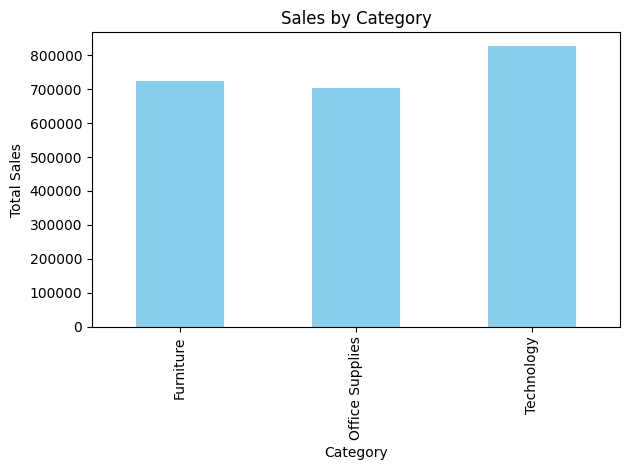

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

# Bar Chart
category_sales.plot(kind='bar', color='skyblue')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

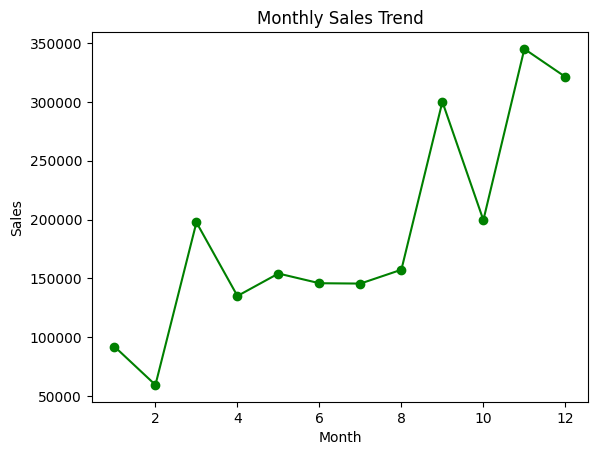

In [11]:
# Monthly Sales Trend
monthly = df.groupby('Month')['Sales'].sum()
monthly.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

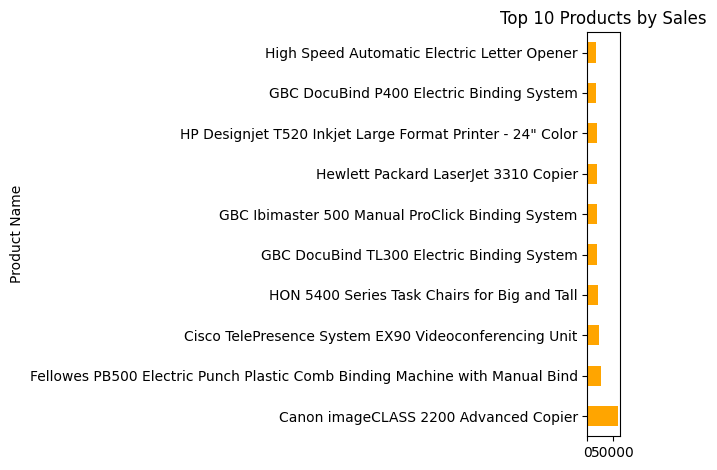

In [12]:
# Top 10 Products
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
top_products.plot(kind='barh', color='orange')
plt.title('Top 10 Products by Sales')
plt.tight_layout()
plt.show()

📌 Key Findings:
1. Technology category has the highest sales
2. Sales peak during November and December
3. Top product is [name from your data]
4. Tools used: Python, Pandas, Matplotlib, Seaborn